### Load Data and perform cleaning

In [4]:
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath(".."))
from etl.extractors import load_data
from etl.transform import transform
from etl.validate import validate_data


In [5]:
df=load_data("../data/raw/SuperstoreData.csv",encoded_system="ISO-8859-1")
df.head()

2026-03-21 18:11:21,484 - etl.extractors -INFO - Loaded 9800 rows and 18 columns


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [6]:
df.tail()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [7]:
df.dtypes

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.shape

(9800, 18)

In [10]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [11]:
df.isna().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [12]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [13]:
df=df.drop(columns=['Postal_Code'])

In [14]:
df.isna().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64

In [15]:
df.dtypes

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
dtype: object

In [16]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [17]:
df.duplicated().sum()

np.int64(0)

## Distribution Analysis

### Boxplot Visualization
A boxplot displays the distribution of numerical data through quartiles:
- **Box**: Contains 50% of the data (Interquartile Range - IQR)
- **Orange line inside box**: Median value (50th percentile)
- **Whiskers**: Extend to ±1.5 × IQR from quartiles
- **Dots beyond whiskers**: Potential outliers

Useful for identifying data spread, skewness, and anomalies across all numerical features.

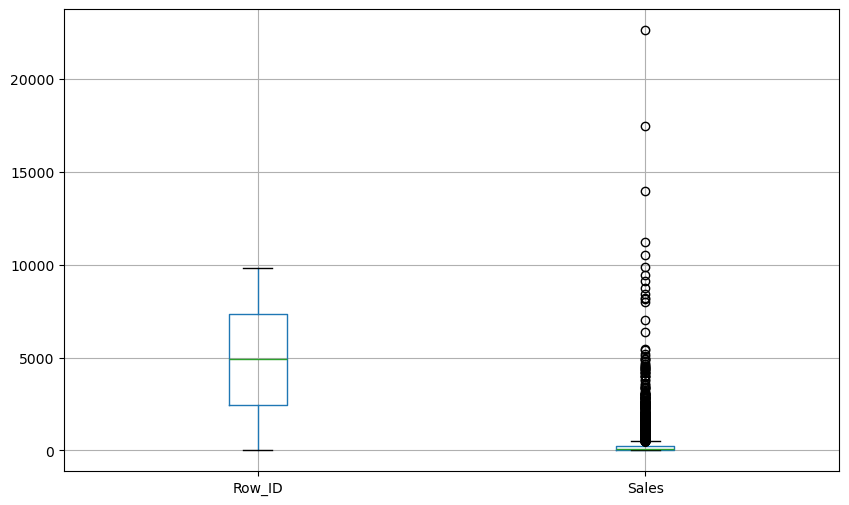

In [18]:
df.boxplot(figsize=(10,6))
plt.show()

### Plot Insight (Boxplot)
From the boxplot, a few numerical features show points beyond the whiskers, which indicates potential outliers.

**Observation:** The `Sales` feature appears to contain high-value outliers.

**Interpretation:**
- Most transactions are concentrated in lower-to-mid sales ranges.
- A small number of records have very high sales values.
- These extreme values can strongly affect mean-based statistics and model training.

### Histogram Visualization
Histograms show the frequency distribution of numerical values:
- **X-axis**: Value ranges (bins) of the feature
- **Y-axis**: Frequency (count) of values in each bin
- **Shape**: Reveals data distribution pattern (normal, skewed, bimodal, etc.)

Histograms help identify:
- **Skewness**: Left/right skewed vs. symmetric distribution
- **Peaks**: Concentration of values
- **Range**: Minimum and maximum spread of data

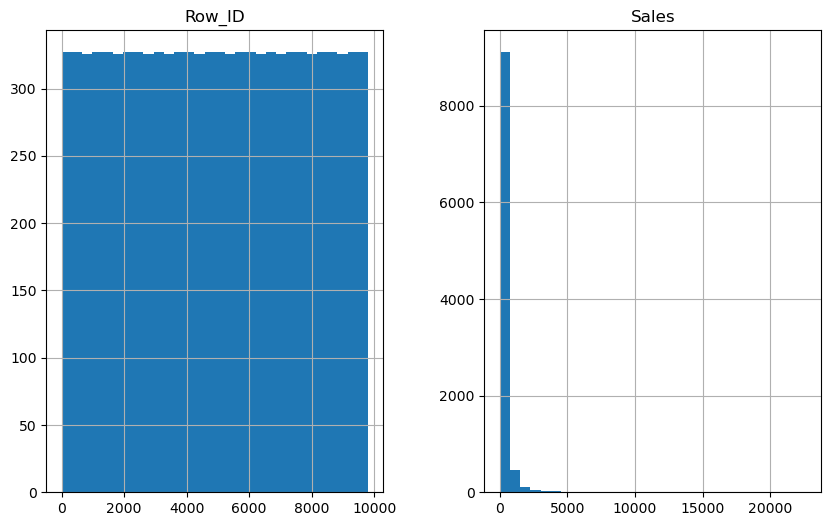

In [19]:
df.hist(figsize=(10,6),bins=30)
plt.show()

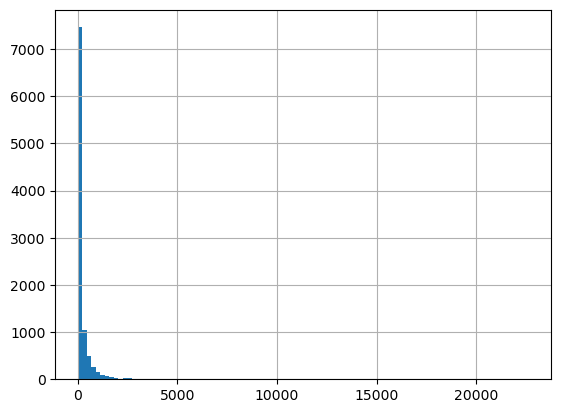

In [20]:
df['Sales'].hist(bins=100)
plt.show()

### Plot Insight (Sales Histogram)
The Sales histogram is **right-skewed** (positively skewed):
- Most orders are in lower sales bins.
- Frequency decreases as sales value increases.
- A long right tail confirms the presence of high-sales outliers.

**Conclusion:** `Sales` is not normally distributed and may benefit from transformation (for example, `log1p(Sales)`) before modeling.

### Categorical Analysis

In [21]:
categorical_data=df.select_dtypes(include=['object','category'])

In [22]:
categorical_data.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name
0,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System


In [23]:
categorical_data['Country'].value_counts()

Country
United States    9800
Name: count, dtype: int64

In [24]:
categorical_data['Country'].unique()

array(['United States'], dtype=object)

In [25]:
categorical_data['City'].unique()

array(['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord',
       'Seattle', 'Fort Worth', 'Madison', 'West Jordan', 'San Francisco',
       'Fremont', 'Philadelphia', 'Orem', 'Houston', 'Richardson',
       'Naperville', 'Melbourne', 'Eagan', 'Westland', 'Dover',
       'New Albany', 'New York City', 'Troy', 'Chicago', 'Gilbert',
       'Springfield', 'Jackson', 'Memphis', 'Decatur', 'Durham',
       'Columbia', 'Rochester', 'Minneapolis', 'Portland', 'Saint Paul',
       'Aurora', 'Charlotte', 'Orland Park', 'Urbandale', 'Columbus',
       'Bristol', 'Wilmington', 'Bloomington', 'Phoenix', 'Roseville',
       'Independence', 'Pasadena', 'Newark', 'Franklin', 'Scottsdale',
       'San Jose', 'Edmond', 'Carlsbad', 'San Antonio', 'Monroe',
       'Fairfield', 'Grand Prairie', 'Redlands', 'Hamilton', 'Westfield',
       'Akron', 'Denver', 'Dallas', 'Whittier', 'Saginaw', 'Medina',
       'Dublin', 'Detroit', 'Tampa', 'Santa Clara', 'Lakeville',
       'San Diego', 'Brentwood', 'Cha

In [26]:
cat_columns=categorical_data.columns
cat_columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID',
       'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product_ID', 'Category', 'Sub_Category', 'Product_Name'],
      dtype='object')

In [27]:
cat_summary = pd.DataFrame({
    'column': cat_columns,
    'missing': [categorical_data[col].isna().sum() for col in cat_columns],
    'unique_values': [categorical_data[col].nunique(dropna=False) for col in cat_columns]
}).sort_values('unique_values', ascending=False).reset_index(drop=True)

cat_summary

,column,missing,unique_values
0,Order_ID,0,4922
1,Product_ID,0,1861
2,Product_Name,0,1849
3,Ship_Date,0,1326
4,Order_Date,0,1230
5,Customer_ID,0,793
6,Customer_Name,0,793
7,City,0,529
8,State,0,49
9,Sub_Category,0,17


In [28]:
categorical_data['Category'].head()

0          Furniture
1          Furniture
2    Office Supplies
3          Furniture
4    Office Supplies
Name: Category, dtype: object

/tmp/ipykernel_1094/3147872814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
/tmp/ipykernel_1094/3147872814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
/tmp/ipykernel_1094/3147872814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")


/tmp/ipykernel_1094/3147872814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")


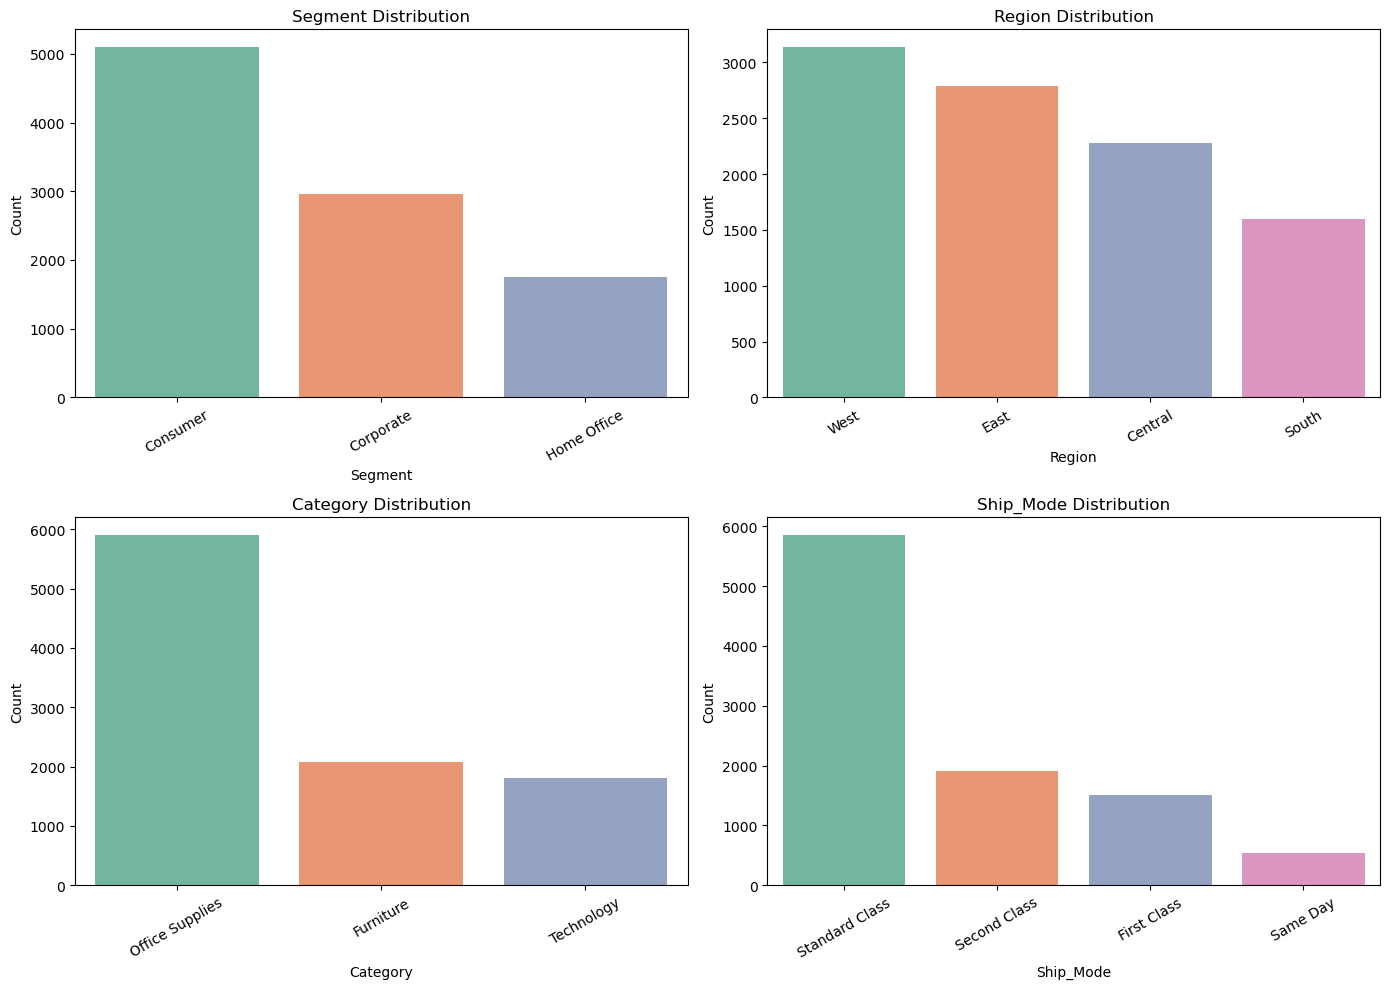

In [29]:
low_card_cols = ["Segment", "Region", "Category", "Ship_Mode"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(low_card_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1094/1580978101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=top_order, palette="viridis")


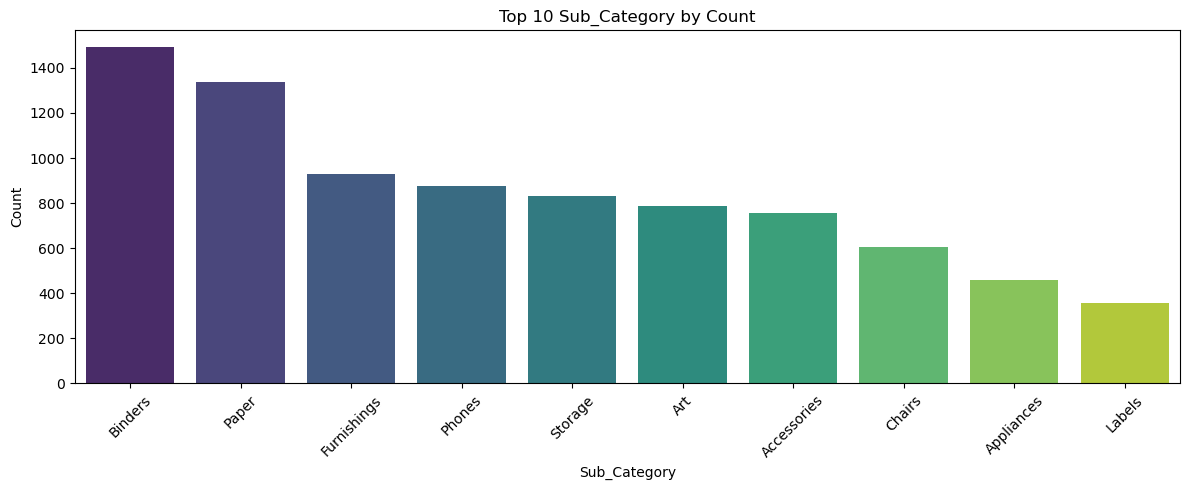

In [30]:
top_n = 10
col = "Sub_Category"
top_order = df[col].value_counts().head(top_n).index

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x=col, order=top_order, palette="viridis")
plt.title(f"Top {top_n} {col} by Count")
plt.xlabel(col)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1094/1068503951.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=top_order, palette="magma")


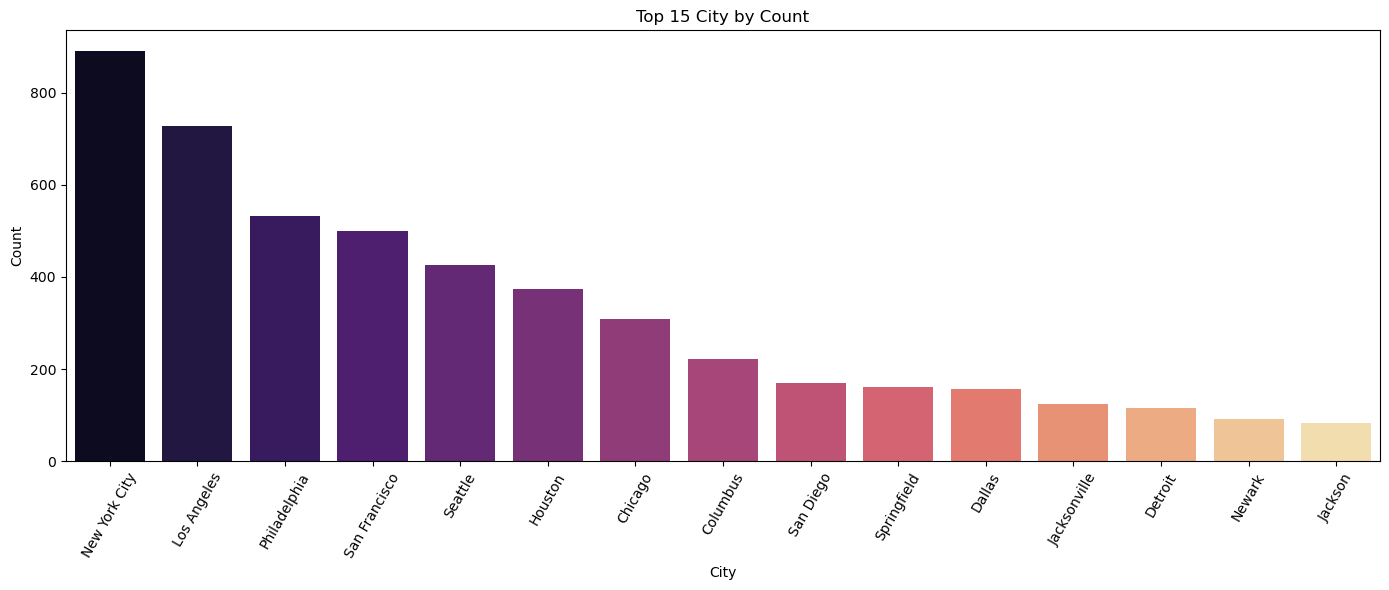

In [31]:
top_n = 15
col = "City"
top_order = df[col].value_counts().head(top_n).index

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x=col, order=top_order, palette="magma")
plt.title(f"Top {top_n} {col} by Count")
plt.xlabel(col)
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

### Plot Insights (Categorical)
- Segment and Region distributions show class imbalance in some groups.
- Category-level distribution highlights dominant product families.
- Sub_Category and City are high-cardinality; only top-N categories are plotted for readability.
- These findings guide encoding strategy:
  - Low-cardinality columns: one-hot encoding
  - High-cardinality columns: frequency/target encoding or grouping rare levels as Other

In [32]:
cat_table_rare = pd.DataFrame({
    'column': cat_columns,
    'rare_cases': [
        categorical_data[col].value_counts()[categorical_data[col].value_counts() < 20].index.tolist()
        for col in cat_columns
    ]
})
cat_table_rare

,column,rare_cases
0,Order_ID,"[CA-2018-100111, CA-2018-157987, US-2017-10850..."
1,Order_Date,"[31/10/2015, 14/09/2015, 5/11/2017, 24/12/2016..."
2,Ship_Date,"[9/12/2018, 30/11/2017, 14/11/2016, 21/03/2015..."
3,Ship_Mode,[]
4,Customer_ID,"[PF-19120, SN-20710, TB-21250, JM-15250, CV-12..."
5,Customer_Name,"[Peter Fuller, Steve Nguyen, Tim Brockman, Jan..."
6,Segment,[]
7,Country,[]
8,City,"[Anaheim, El Paso, Mcallen, Des Moines, Dover,..."
9,State,"[Montana, South Dakota, Vermont, District of C..."


In [33]:
df.isna().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64

In [34]:
df.to_csv("../data/processed/cleansuperstoredata.csv",index=False)

In [35]:
df=load_data("../data/processed/cleansuperstoredata.csv",encoded_system="ISO-8859-1")

2026-03-21 18:11:25,922 - etl.extractors -INFO - Loaded 9800 rows and 17 columns


In [36]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [37]:
df.isna().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64

In [38]:
transformed_df=transform(df,order_date_col="Order_Date",ship_date_col="Ship_Date")

2026-03-21 18:11:26,042 - etl.transform -INFO - Transformation started
2026-03-21 18:11:26,084 - etl.transform -INFO - Converted Order_Date to datetime
2026-03-21 18:11:26,102 - etl.transform -INFO - Converted Ship_Date to datetime
2026-03-21 18:11:26,144 - etl.transform -INFO - Date-based feature engineering completed
2026-03-21 18:11:26,251 - etl.transform -INFO - Cleaned categorical columns: ['Order_ID', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Order_Weekday', 'Ship_Weekday']
2026-03-21 18:11:26,315 - etl.transform -INFO - Removed duplicates: 0 rows dropped
2026-03-21 18:11:26,319 - etl.transform -INFO - transformation completed


In [39]:
transformed_df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Category,Sub_Category,Product_Name,Sales,Order_Year,Order_Month,Order_Weekday,Ship_Year,Ship_Month,Ship_Weekday
0,1,ca-2017-152156,2017-08-11,2017-11-11,second class,cg-12520,claire gute,consumer,united states,henderson,...,furniture,bookcases,bush somerset collection bookcase,261.9600,2017.0,8.0,friday,2017.0,11.0,saturday
1,2,ca-2017-152156,2017-08-11,2017-11-11,second class,cg-12520,claire gute,consumer,united states,henderson,...,furniture,chairs,"hon deluxe fabric upholstered stacking chairs,...",731.9400,2017.0,8.0,friday,2017.0,11.0,saturday
2,3,ca-2017-138688,2017-12-06,NaT,second class,dv-13045,darrin van huff,corporate,united states,los angeles,...,office supplies,labels,self-adhesive address labels for typewriters b...,14.6200,2017.0,12.0,wednesday,NaN,NaN,<NA>
3,4,us-2016-108966,2016-11-10,NaT,standard class,so-20335,sean o donnel,consumer,united states,fort lauderdale,...,furniture,tables,bretford cr4500 series slim rectangular table,957.5775,2016.0,11.0,thursday,NaN,NaN,<NA>
4,5,us-2016-108966,2016-11-10,NaT,standard class,so-20335,sean o donnel,consumer,united states,fort lauderdale,...,office supplies,storage,eldon fold n roll cart system,22.3680,2016.0,11.0,thursday,NaN,NaN,<NA>


In [40]:
transformed_df.dtypes

Row_ID                    int64
Order_ID         string[python]
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Ship_Mode        string[python]
Customer_ID      string[python]
Customer_Name    string[python]
Segment          string[python]
Country          string[python]
City             string[python]
State            string[python]
Region           string[python]
Product_ID       string[python]
Category         string[python]
Sub_Category     string[python]
Product_Name     string[python]
Sales                   float64
Order_Year              float64
Order_Month             float64
Order_Weekday    string[python]
Ship_Year               float64
Ship_Month              float64
Ship_Weekday     string[python]
dtype: object

In [41]:
salesperYear=(
    transformed_df.groupby("Order_Year")['Sales']
    .sum()
   
)


In [42]:
salesperYear.head()

Order_Year
2015.0    176986.5857
2016.0    162568.8627
2017.0    266254.6009
2018.0    266553.0743
Name: Sales, dtype: float64

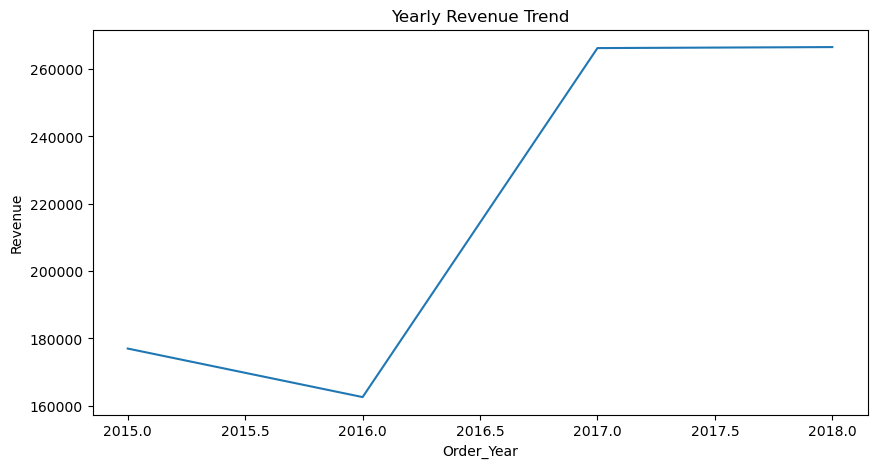

In [43]:
salesperYear.plot(figsize=(10,5))
plt.title("Yearly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

## 📈 Revenue Trend Analysis (2015–2018)

- **2015**: Sales began at a moderate level, reaching approximately **177,000**.  
  This year serves as the baseline of the observed trend.

- **2016**: Revenue experienced a slight decline, dipping to around **162,000**,  
  suggesting possible market or operational challenges.

- **2017**: A significant surge followed, with sales climbing to nearly **266,200**.  
  This sharp increase highlights a strong growth phase, potentially driven by higher demand or improved business strategies.

- **2018**: The upward momentum continued, with sales sustaining levels similar to 2017,  
  confirming that the growth was not a one‑time anomaly but part of a stable trend.

In [44]:
Monthly_sales=(
    transformed_df.groupby(["Order_Year","Order_Month"])['Sales'].sum().reset_index()
)
print(Monthly_sales.head())



   Order_Year  Order_Month      Sales
0      2015.0          1.0  19546.163
1      2015.0          2.0  11678.994
2      2015.0          3.0   6716.044
3      2015.0          4.0  12455.482
4      2015.0          5.0  15165.051


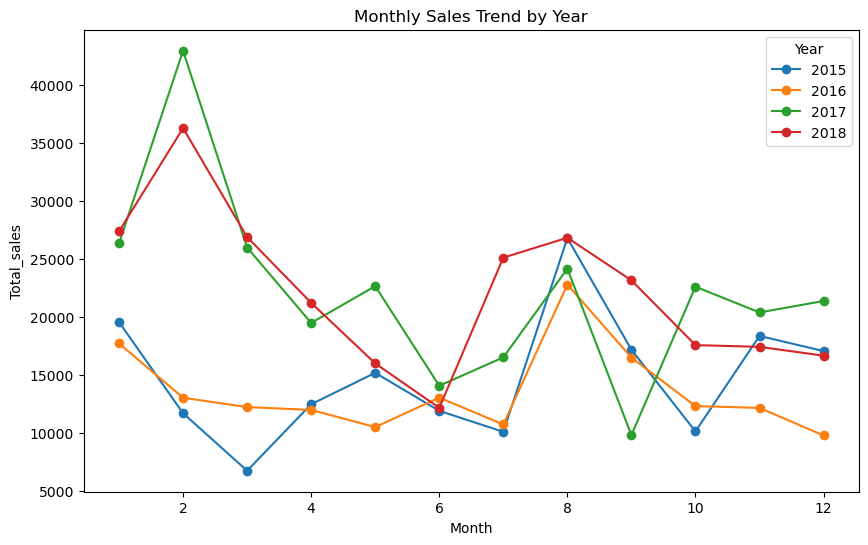

In [45]:
plt.figure(figsize=(10,6))
for year in Monthly_sales['Order_Year'].unique():
    subset=Monthly_sales[Monthly_sales['Order_Year']==year]
    plt.plot(subset['Order_Month'],subset['Sales'],marker='o',label=str(int(year)))
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total_sales")
plt.legend(title='Year')
plt.show()

### Sales Trend Analysis

- Overall, **2018 generated the highest revenue**, indicating an improvement in sales performance over the years.

- From the graph, **sales consistently increase from July to August across all years**, suggesting a **seasonal rise in demand during this period**.

- A significant peak is observed in **February for 2017 and 2018**, compared to relatively lower sales in 2015 and 2016. This indicates that **sales performance improved in later years during this month**, possibly due to factors such as promotions or increased customer demand.

- Sales show fluctuations throughout the year, but certain months such as **February and August consistently demonstrate higher performance**.

In [46]:
#converting it into wide format
Pivot_table=Monthly_sales.pivot(index='Order_Month',columns='Order_Year',values='Sales')

In [47]:
print(type(Pivot_table))
Pivot_table

<class 'pandas.core.frame.DataFrame'>


Order_Year,2015.0,2016.0,2017.0,2018.0
Order_Month,,,,
1.0,19546.1630,17701.6864,26342.5410,27367.5920
2.0,11678.9940,13018.3150,42967.9150,36285.9360
3.0,6716.0440,12207.4066,25982.2870,26882.9530
4.0,12455.4820,11963.6960,19472.1640,21203.6070
5.0,15165.0510,10483.4820,22649.3888,15979.1570
6.0,11884.1690,13026.6682,14050.1430,12138.1558
7.0,10075.7400,10706.7200,16501.0070,25110.4795
8.0,26797.7630,22782.5770,24156.3226,26823.6900
9.0,17158.9320,16484.9010,9789.6620,23148.8700


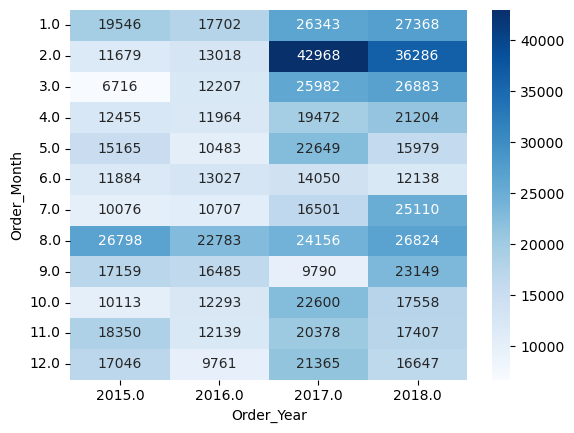

In [48]:
sns.heatmap(Pivot_table,annot=True,fmt='.0f',cmap="Blues")#annot means 
#annnotate each cell with numerical values
plt.show()

In [49]:
transformed_df.corr(numeric_only=True)

,Row_ID,Sales,Order_Year,Order_Month,Ship_Year,Ship_Month
Row_ID,1.000000,0.001151,0.018851,-0.017940,0.026018,-0.008383
Sales,0.001151,1.000000,-0.005242,-0.029634,-0.008463,0.003419
Order_Year,0.018851,-0.005242,1.000000,-0.033570,1.000000,-0.034724
Order_Month,-0.017940,-0.029634,-0.033570,1.000000,0.017784,0.779976
Ship_Year,0.026018,-0.008463,1.000000,0.017784,1.000000,-0.034095
Ship_Month,-0.008383,0.003419,-0.034724,0.779976,-0.034095,1.000000


In [50]:
sales_by_region=(transformed_df.groupby('Region')['Sales'].sum().sort_values(ascending=False))
sales_by_region

Region
west       710219.6845
east       669518.7260
central    492646.9132
south      389151.4590
Name: Sales, dtype: float64

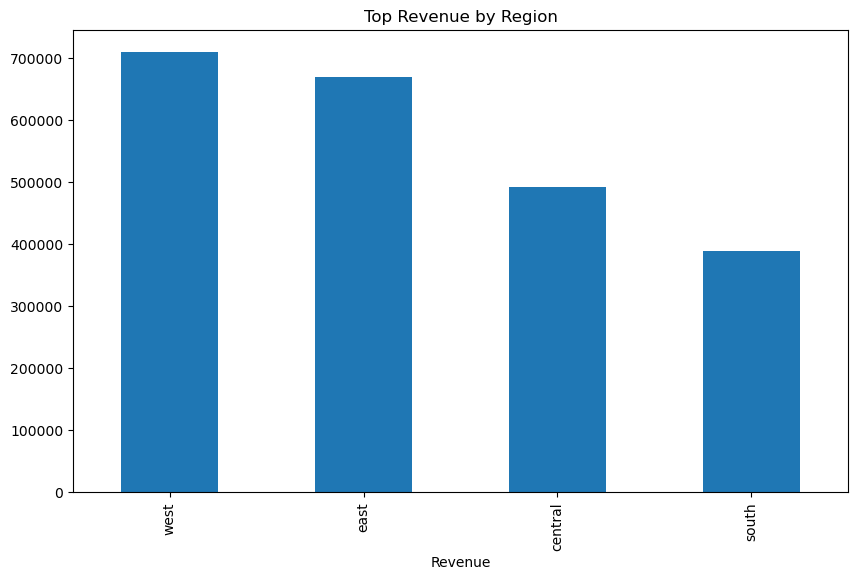

In [51]:
sales_by_region.plot(kind="bar",figsize=(10,6))
plt.title("Top Revenue by Region")
plt.xlabel("Revenue")
plt.show()

In [52]:
customer_by_region_city_state=(
    transformed_df.groupby(['Region','City','State'])['Customer_ID']
    .count()
    .sort_index(ascending=False)
    )
customer_by_region_city_state

Region   City         State       
west     yuma         arizona          4
         yucaipa      california       1
         woodland     california       3
         whittier     california       1
         westminster  california      16
                                      ..
central  ann arbor    michigan         5
         amarillo     texas           10
         allen        texas            4
         abilene      texas            1
         aberdeen     south dakota     1
Name: Customer_ID, Length: 600, dtype: int64

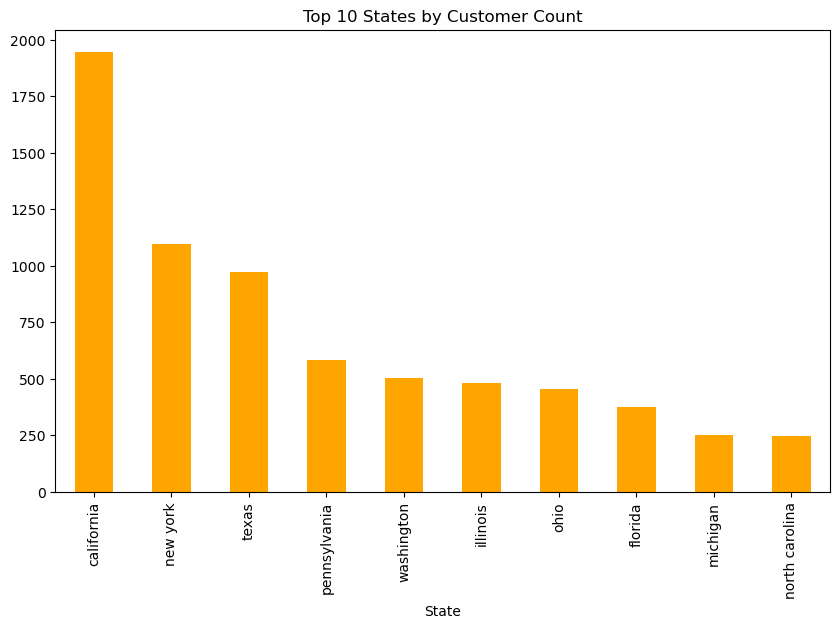

In [53]:
state_customers = transformed_df.groupby("State")["Customer_ID"].count().sort_values(ascending=False).head(10)
state_customers.plot(kind="bar", figsize=(10,6), color="orange")
plt.title("Top 10 States by Customer Count")
plt.show()

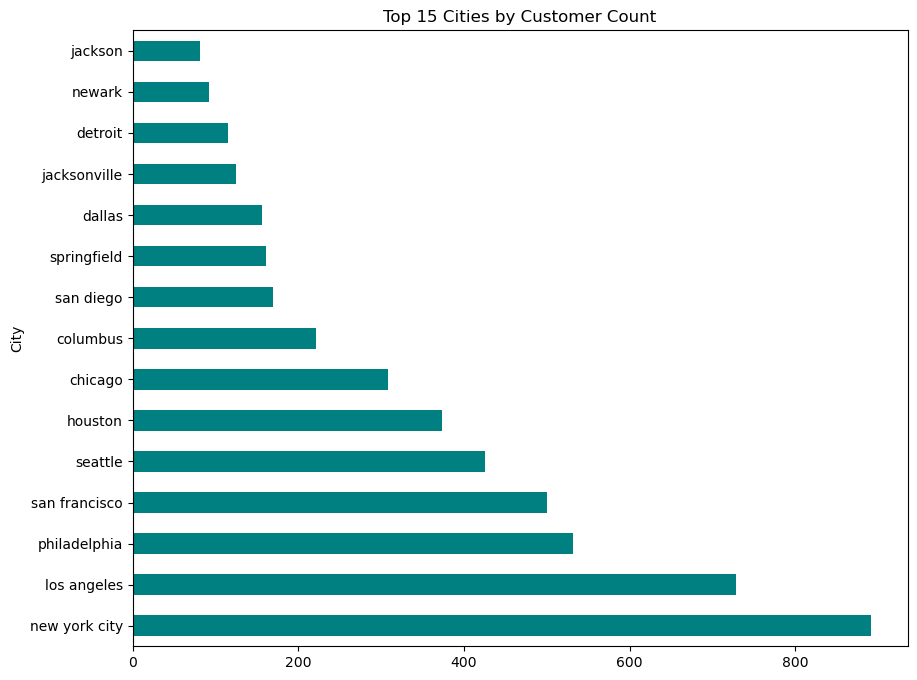

In [54]:
city_customers = transformed_df.groupby("City")["Customer_ID"].count().sort_values(ascending=False).head(15)
city_customers.plot(kind="barh", figsize=(10,8), color="teal")
plt.title("Top 15 Cities by Customer Count")
plt.show()


In [55]:
sale_byCategory=(transformed_df.groupby('Category')['Sales']
                 .sum().sort_values(ascending=False))
sale_byCategory

Category
technology         827455.8730
furniture          728658.5757
office supplies    705422.3340
Name: Sales, dtype: float64

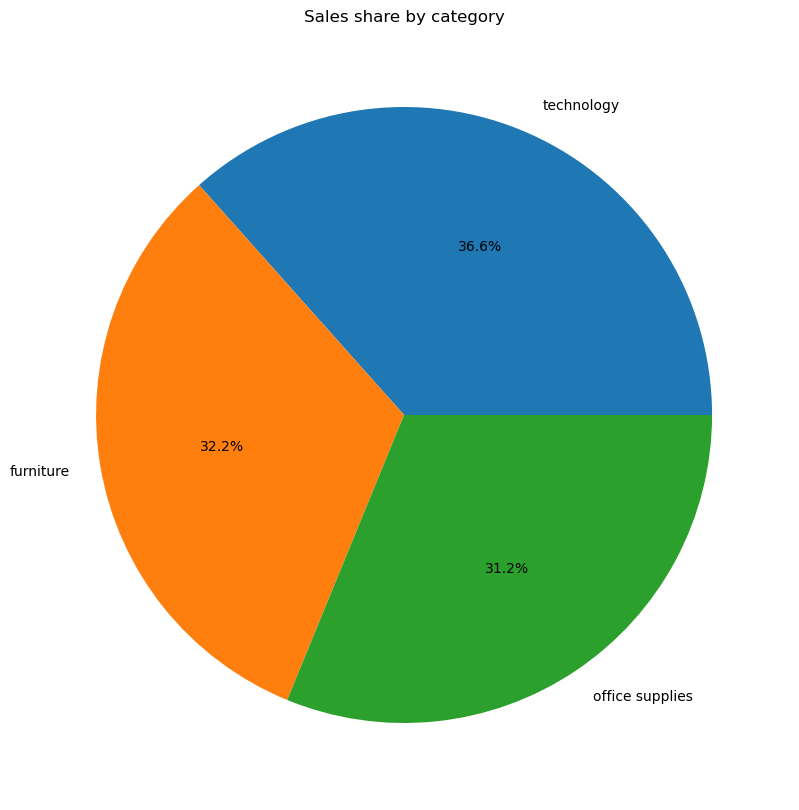

In [56]:
sale_byCategory.plot(kind='pie',autopct='%1.1f%%',figsize=(16,10))
plt.title("Sales share by category")
plt.ylabel("")
plt.show()

In [57]:
salesbySegement=(transformed_df.groupby('Segment')['Sales'].sum().sort_values(ascending=False))
salesbySegement

Segment
consumer       1.148061e+06
corporate      6.884941e+05
home office    4.249822e+05
Name: Sales, dtype: float64

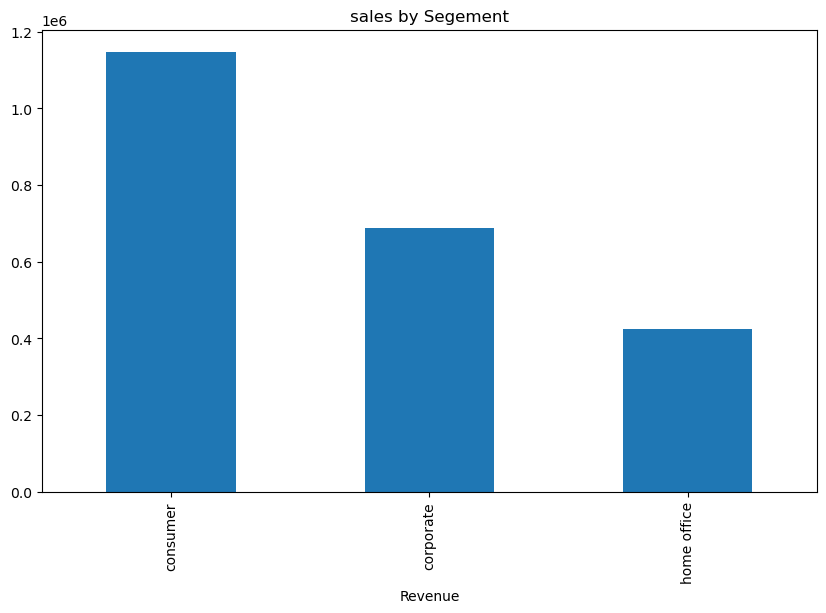

In [58]:
salesbySegement.plot(kind="bar",figsize=(10,6))
plt.title("sales by Segement")
plt.xlabel("Revenue")
plt.show()


### revenue generated
- most revenue is generated by B2C business to consumer.

In [59]:
topCustomer=(transformed_df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10))
topCustomer


Customer_Name
sean miller           25043.050
tamara chand          19052.218
raymond buch          15117.339
tom ashbrook          14595.620
adrian barton         14473.571
ken lonsdale          14175.229
sanjit chand          14142.334
hunter lopez          12873.298
sanjit engle          12209.438
christopher conant    12129.072
Name: Sales, dtype: float64

In [60]:
category_sales = transformed_df.groupby("Category")["Sales"].sum()
subcat_sales = transformed_df.groupby("Sub_Category")["Sales"].sum().sort_values(ascending=False)


In [61]:
subcat_sales

Sub_Category
phones         327782.4480
chairs         322822.7310
storage        219343.3920
tables         202810.6280
binders        200028.7850
machines       189238.6310
accessories    164186.7000
copiers        146248.0940
bookcases      113813.1987
appliances     104618.4030
furnishings     89212.0180
paper           76828.3040
supplies        46420.3080
art             26705.4100
envelopes       16128.0460
labels          12347.7260
fasteners        3001.9600
Name: Sales, dtype: float64

## Ship Date analysis

In [62]:
transformed_df['Ship_lag'] = (
    transformed_df['Ship_Date'] - transformed_df['Order_Date']
).dt.days

In [63]:
ship_lag_trend=(transformed_df.groupby(
    [transformed_df['Order_Year'],transformed_df['Order_Month']])['Ship_lag'].mean(
        
    ))

In [64]:
ship_lag_trend

Order_Year  Order_Month
2015.0      1.0            127.585714
            2.0            126.546875
            3.0            117.740741
            4.0            132.350000
            5.0            114.400000
            6.0            125.293103
            7.0            117.358491
            8.0            102.387097
            9.0             54.473684
            10.0             0.000000
            11.0                  NaN
            12.0             0.000000
2016.0      1.0            126.177419
            2.0            120.430769
            3.0            120.876923
            4.0            120.961538
            5.0            125.952381
            6.0            123.214286
            7.0            105.135593
            8.0             80.232558
            9.0             77.166667
            10.0             8.363636
            11.0            22.941176
            12.0                  NaN
2017.0      1.0             92.845361
            2.0           

In [65]:
ship_mode_perf = transformed_df.groupby("Ship_Mode")["Ship_lag"].mean()
ship_mode_perf

Ship_Mode
first class        62.839695
same day            1.958506
second class       96.998095
standard class    145.769841
Name: Ship_lag, dtype: float64

In [66]:
region_ship_lag = transformed_df.groupby("Region")["Ship_lag"].mean().sort_values()
region_ship_lag

Region
south      103.345815
west       104.013597
east       107.778636
central    112.501572
Name: Ship_lag, dtype: float64

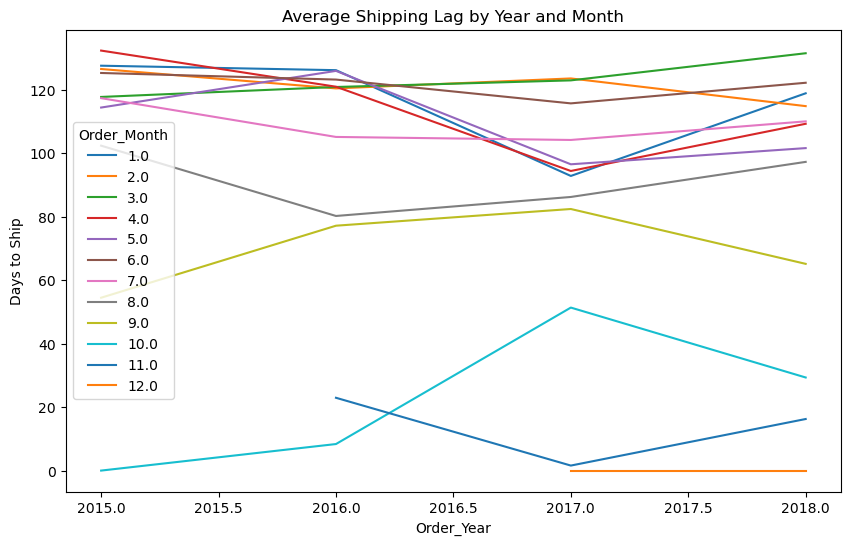

In [67]:
ship_lag_trend.unstack().plot(figsize=(10,6))
plt.title("Average Shipping Lag by Year and Month")
plt.ylabel("Days to Ship")
plt.show()

### Shipping Lag Trend Analysis

- The average shipping lag (days to ship) shows **moderate variation across years**, without a clear long-term increasing or decreasing trend.

- Most months maintain a **relatively consistent shipping time**, indicating stable logistics performance across the years.

- A noticeable **dip in shipping lag occurs around 2017 for several months**, suggesting improved shipping efficiency during that period.

- Some months (such as early and mid-year months) show **slightly higher shipping delays**, which may indicate increased order volume or operational constraints during those periods.

- Overall, the shipping process appears **fairly stable**, with only minor fluctuations, indicating a well-maintained supply chain system.

In [68]:
transformed_df.dtypes

Row_ID                    int64
Order_ID         string[python]
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Ship_Mode        string[python]
Customer_ID      string[python]
Customer_Name    string[python]
Segment          string[python]
Country          string[python]
City             string[python]
State            string[python]
Region           string[python]
Product_ID       string[python]
Category         string[python]
Sub_Category     string[python]
Product_Name     string[python]
Sales                   float64
Order_Year              float64
Order_Month             float64
Order_Weekday    string[python]
Ship_Year               float64
Ship_Month              float64
Ship_Weekday     string[python]
Ship_lag                float64
dtype: object

In [69]:
validate_data(transformed_df)

2026-03-21 18:11:30,112 - etl.validate -INFO - Validation started
2026-03-21 18:11:30,115 - etl.validate -INFO - All required columns are present
2026-03-21 18:11:30,159 - etl.validate -INFO - Duplicate rows: 0
2026-03-21 18:11:30,163 - etl.validate -INFO - Negative sales rows: 0
2026-03-21 18:11:30,173 - etl.validate -INFO - Invalid date rows (Ship < Order): 0
2026-03-21 18:11:30,175 - etl.validate -INFO - Validation passed successfully


True